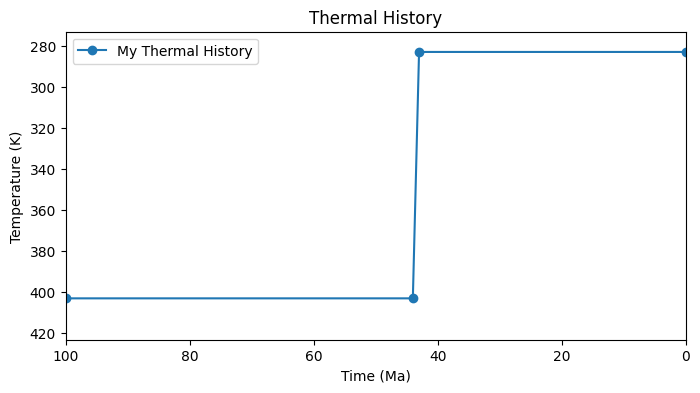


=== AFT RESULTS TABLE ===
         Model  AFT_age_Ma  Mean_track_length_um     Sigma  Central_age_Ma  \
0  Ketcham1999        44.0             45.034291  0.514103          175.57   

   Central_age_se  Pooled_age_Ma  Pooled_age_se      Chi2  
0            8.51         175.57           9.88  0.929213  


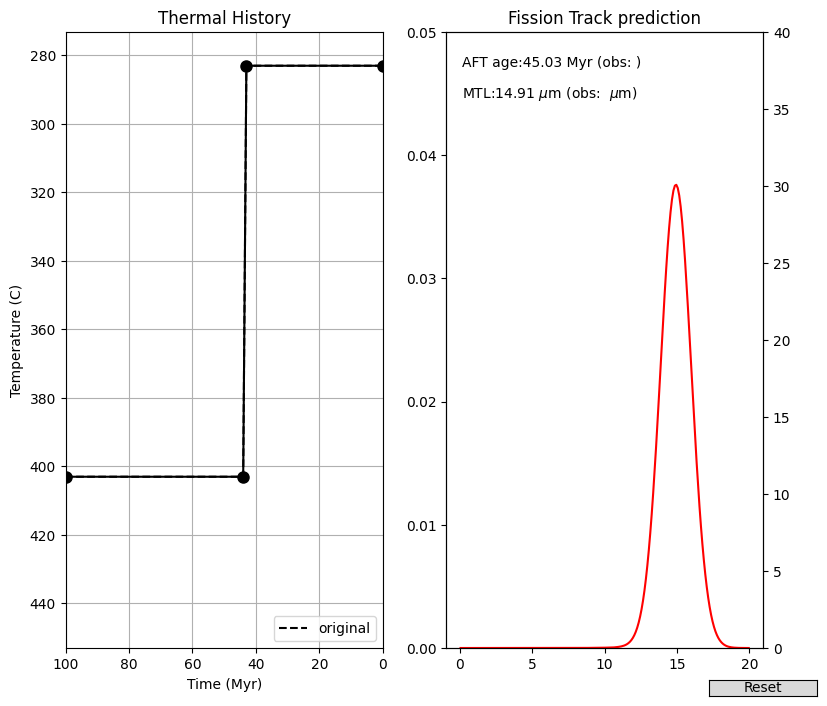

In [ ]:
# ============================================================
# PYFTRACKS — MODULAR AFT FRAMEWORK
# Estrutura: CONFIG → BUILD → RUN → OUTPUT
# ============================================================

import pyFTracks as FT
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 0) CONFIGURAÇÃO DO EXPERIMENTO (ÚNICO BLOCO A ALTERAR)
# ============================================================

CONFIG = {
    # ---- História térmica ----
    "thermal_history": {
        "name": "My Thermal History",
        "time": [0., 43., 44., 100.],
        "temperature": [283., 283., 403., 403.]
    },
    
    # ---- Modelo cinético ----
    "model": {
        "type": "Ketcham1999",   # opções: "Ketcham1999", "Ketcham2007"
        "ETCH_PIT_LENGTH": 1.65
    },
    
    # ---- Dados AFT (ζ-method) ----
    "aft_data": {
        "Ns": [31, 19, 56, 67, 88, 6, 18, 40, 36, 54, 35, 52, 51, 47, 27, 36, 64, 68, 61, 30],
        "Ni": [41, 22, 63, 71, 90, 7, 14, 41, 49, 79, 52, 76, 74, 66, 39, 44, 86, 90, 91, 41],
        "zeta": 350.,
        "zeta_err": 10./350.,
        "rhod": 1.304,
        "Nd": 2936
    }
}


# ============================================================
# 1) BUILD — História térmica
# ============================================================

def build_thermal_history(cfg):
    return FT.ThermalHistory(
        name=cfg["name"],
        time=cfg["time"],
        temperature=cfg["temperature"]
    )

thermal_history = build_thermal_history(CONFIG["thermal_history"])


# ============================================================
# 2) BUILD — Modelo cinético
# ============================================================

def build_model(cfg, thermal_history):
    model_type = cfg["type"]
    params = {"ETCH_PIT_LENGTH": cfg["ETCH_PIT_LENGTH"]}
    
    if model_type == "Ketcham1999":
        model = FT.Ketcham1999(kinetic_parameters=params)
    elif model_type == "Ketcham2007":
        model = FT.Ketcham2007(kinetic_parameters=params)
    else:
        raise ValueError(f"Modelo não suportado: {model_type}")
    
    model.history = thermal_history
    return model

annealing_model = build_model(CONFIG["model"], thermal_history)


# ============================================================
# 3) RUN — Forward modelling AFT
# ============================================================

aft_age, mtl, sigma = annealing_model.calculate_age()


# ============================================================
# 4) RUN — Estatística AFT (ζ-method)
# ============================================================

def run_aft_statistics(cfg):
    Ns = cfg["Ns"]
    Ni = cfg["Ni"]
    zeta = cfg["zeta"]
    zeta_err = cfg["zeta_err"]
    rhod = cfg["rhod"]
    Nd = cfg["Nd"]
    
    central = FT.central_age(Ns, Ni, zeta, zeta_err, rhod, Nd)
    pooled = FT.pooled_age(Ns, Ni, zeta, zeta_err, rhod, Nd)
    single = FT.single_grain_ages(Ns, Ni, zeta, zeta_err, rhod, Nd)
    chi2 = FT.chi2_test(Ns, Ni)
    
    return central, pooled, single, chi2

central_age, pooled_age, single_grain, chi2 = run_aft_statistics(CONFIG["aft_data"])


# ============================================================
# 5) OUTPUT — Tabela de resultados
# ============================================================

def build_results_table():
    return pd.DataFrame({
        "Thermal_history": [CONFIG["thermal_history"]["name"]],
        "Model": [CONFIG["model"]["type"]],
        "ETCH_PIT_LENGTH": [CONFIG["model"]["ETCH_PIT_LENGTH"]],
        "AFT_age_Ma": [aft_age],
        "Mean_track_length_um": [mtl],
        "Sigma": [sigma],
        "Central_age_Ma": [central_age["Central"]],
        "Central_age_se": [central_age["se"]],
        "Pooled_age_Ma": [pooled_age["Pooled Age"]],
        "Pooled_age_se": [pooled_age["se"]],
        "Chi2": [chi2]
    })

df_results = build_results_table()
print("\n=== AFT RESULTS TABLE ===")
print(df_results)


# ============================================================
# 6) OUTPUT — Gráficos
# ============================================================

# História térmica
plt.figure(figsize=(8, 4))
plt.plot(thermal_history.input_time, thermal_history.input_temperature,
         label=thermal_history.name, marker="o")
plt.xlim(100., 0.)
plt.ylim(150. + 273.15, 0. + 273.15)
plt.ylabel("Temperature (K)")
plt.xlabel("Time (Ma)")
plt.legend()
plt.title("Thermal History")
plt.show()

# Viewer do pyFTracks
FT.Viewer(history=thermal_history, annealing_model=annealing_model)
